# ABC B-lineage Single-Cell Analysis

This notebook loads `abc_B_lineage_processed.h5ad` and performs:
- Rank genes per cell_type and plot top markers (heatmap, tracksplot, violin)
- UMAP visualization with consistent cell-type colors
- Dotplot of marker genes (3�C5 per cell type)
- KEGG/GO enrichment with metabolic pathways highlighted

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import rc_context

In [3]:
abc_ad = sc.read_h5ad("./data/abc_B_lineage_processed.h5ad")
abc_ad

AnnData object with n_obs × n_vars = 938 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'data'
    obsp: 'connectivities', 'dist

In [4]:
# Output dirs
out_dir = Path("./results/figure_sc")
out_dir.mkdir(parents=True, exist_ok=True)
out_fig3 = Path("./results/figure3")
out_fig3.mkdir(parents=True, exist_ok=True)

In [5]:
# Fixed cell type order and hard-coded colors (match LDA plots)
ORDER = ["HSC", "Pro B", "Pre B", "Naive B"]
class_color_map = {
    "HSC": "#1f77b4",    # blue
    "Pro B": "#17becf",  # cyan
    "Pre B": "#e377c2",  # pink
    "Naive B": "#d62728" # red
}
classes = np.array(ORDER)
abc_ad.obs["cell_type"] = pd.Categorical(abc_ad.obs["cell_type"], categories=classes, ordered=True)
abc_ad.uns["cell_type_colors"] = [class_color_map[c] for c in classes]
palette = [class_color_map[c] for c in classes]

cell_type_sorted = abc_ad.obs["cell_type"].astype(str).values
row_colors = np.array([class_color_map[ct] for ct in cell_type_sorted])

## Rank Genes by Cell Type

Compute differential expression using Wilcoxon on `cell_type`.

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


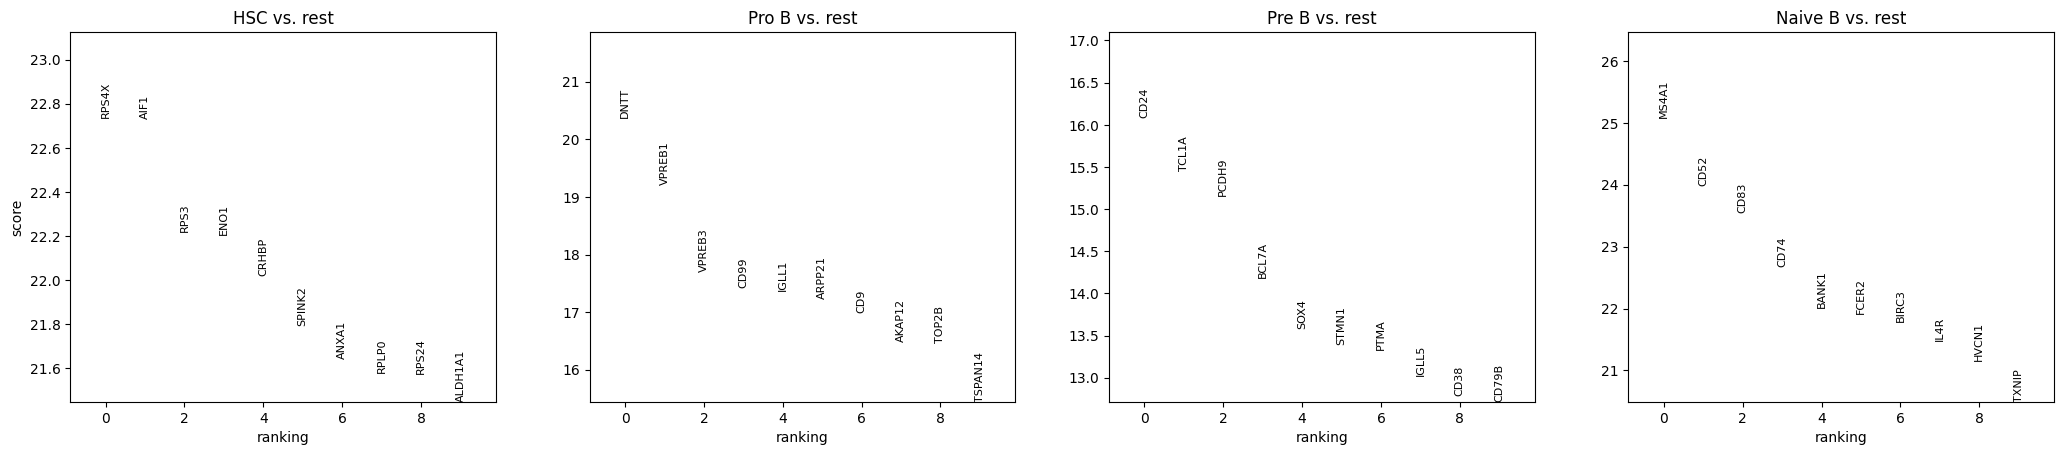

In [6]:
# Ensure log1p metadata exists to satisfy scanpy rank_genes_groups
if "log1p" not in abc_ad.uns:
    abc_ad.uns["log1p"] = {"base": None}
elif "base" not in abc_ad.uns["log1p"]:
    abc_ad.uns["log1p"]["base"] = None

sc.tl.rank_genes_groups(abc_ad, groupby="cell_type", method="wilcoxon",layer="data")
sc.pl.rank_genes_groups(abc_ad, n_genes=10, sharey=False)

## Heatmap / Tracksplot / Violin (Top Markers)

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\tools\_dendrogram.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


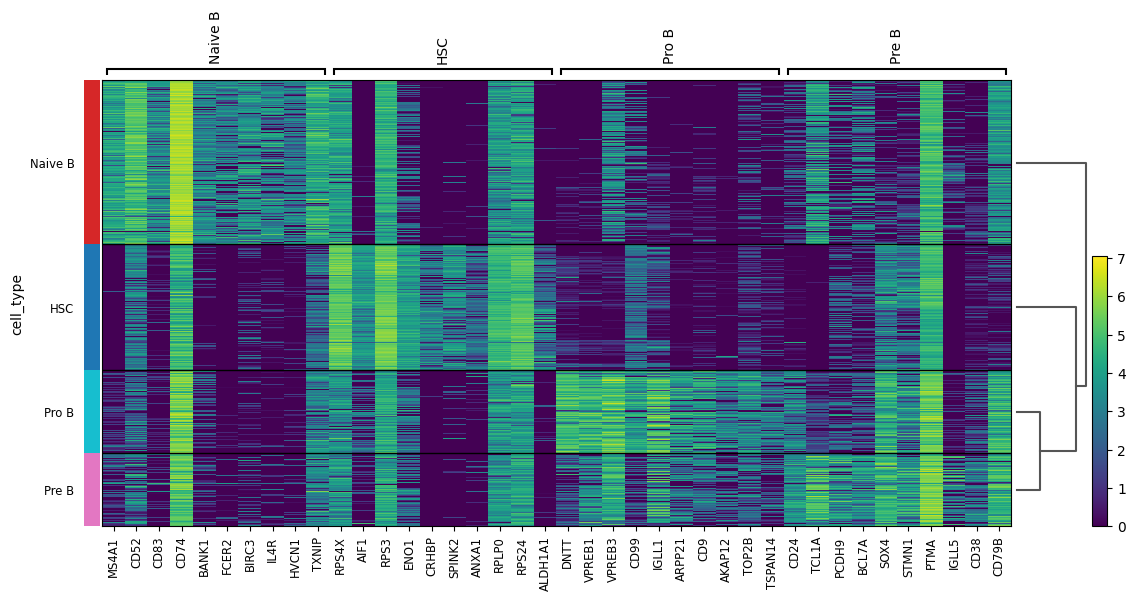

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details.

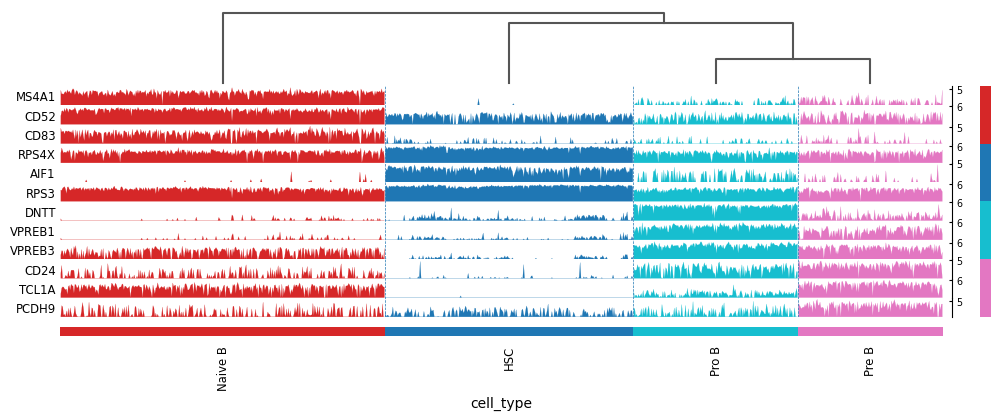

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1171: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  _ax = sns.violinplot(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1184: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  _ax = sns.stripplot(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1200: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation='vertical')


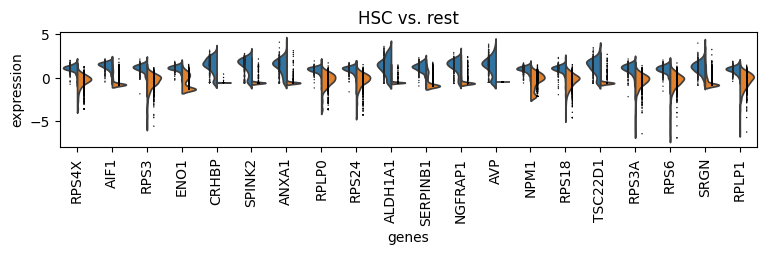

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1171: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  _ax = sns.violinplot(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1184: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  _ax = sns.stripplot(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1200: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation='vertical')


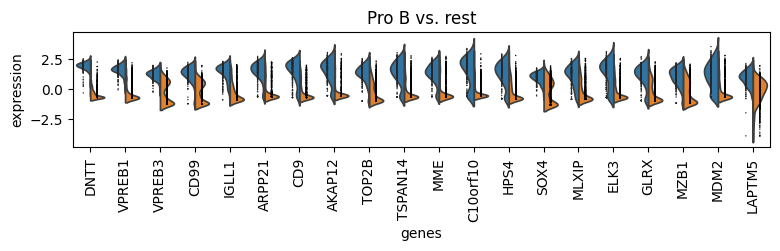

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1171: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  _ax = sns.violinplot(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1184: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  _ax = sns.stripplot(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1200: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation='vertical')


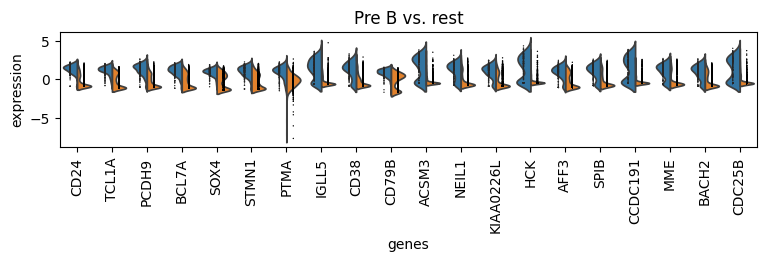

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1171: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  _ax = sns.violinplot(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1184: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  _ax = sns.stripplot(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\__init__.py:1200: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation='vertical')


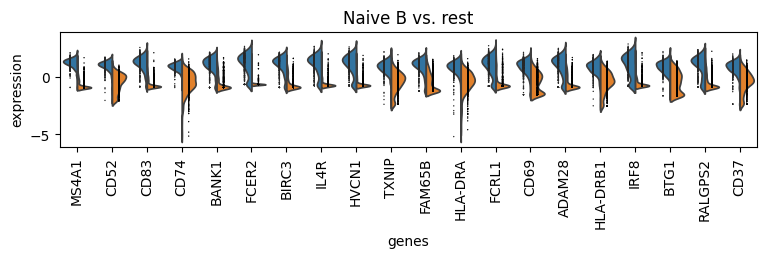

In [7]:
order = ["HSC", "Pro B", "Pre B", "Naive B"]
abc_ad.obs["cell_type"] = pd.Categorical(
    abc_ad.obs["cell_type"], categories=order, ordered=True
)

# Extract top 10 marker genes per cell_type
rg = sc.get.rank_genes_groups_df(abc_ad, group=None)
marker_genes_dict = {ct: rg[rg["group"] == ct].head(10)["names"].tolist() for ct in classes}

# Heatmap (save)
ax = sc.pl.heatmap(abc_ad, marker_genes_dict, groupby="cell_type", cmap="viridis", dendrogram=True, show=False, layer="data")
for ext in ["svg", "png", "pdf"]:
    plt.savefig(out_fig3 / f"celltype_heatmap.{ext}", dpi=300, bbox_inches="tight")
plt.show()

# Tracksplot (save)
sc.pl.rank_genes_groups_tracksplot(abc_ad, n_genes=3, groupby="cell_type", layer="data", show=False)
for ext in ["svg", "png", "pdf"]:
    plt.savefig(out_fig3 / f"celltype_tracksplot.{ext}", dpi=300, bbox_inches="tight")
plt.show()

with rc_context({"figure.figsize": (9, 1.5)}):
    sc.pl.rank_genes_groups_violin(abc_ad, n_genes=20, jitter=False)

In [8]:
rg.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,HSC,RPS4X,22.737995,2.521237,1.886523e-114,1.101876e-110
1,HSC,AIF1,22.730759,5.948403,2.224552e-114,1.101876e-110
2,HSC,RPS3,22.217281,1.786171,2.337993e-109,7.720442e-106
3,HSC,ENO1,22.206562,3.969844,2.967976e-109,8.400645e-106
4,HSC,CRHBP,22.020039,11.758130,1.851093e-107,3.667571e-104


## UMAP by Cell Type

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


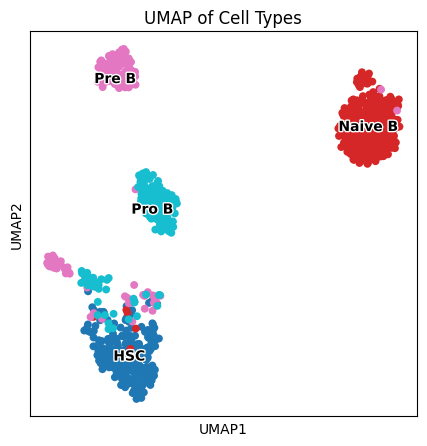

In [9]:
with rc_context({"figure.figsize": (5, 5)}):
    sc.pl.umap(
        abc_ad,
        color="cell_type",
        legend_loc="on data",
        legend_fontsize=10,
        legend_fontoutline=2,
        title="UMAP of Cell Types",
        palette=palette,
        show=False,
    )
    for ext in ["png", "svg", "pdf"]:
        plt.savefig(out_fig3 / f"umap_cell_type.{ext}", dpi=300, bbox_inches="tight")
    plt.show()

## Dotplot of Marker Genes (3-5 per Cell Type)

Select 3�C5 marker genes per cell type based on ranked genes.

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_dotplot.py:169: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_dotplot.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds

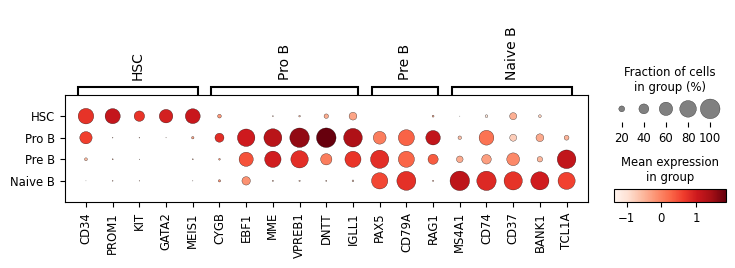

In [63]:
order = ["HSC", "Pro B", "Pre B", "Naive B"]
abc_ad.obs["cell_type"] = pd.Categorical(
    abc_ad.obs["cell_type"].astype(str), categories=order, ordered=True
)
marker_genes_dict_3to5 = {
    "HSC": ["CD34", "PROM1", "KIT", "GATA2", "MEIS1"],
    "Pro B": ["CYGB", "EBF1", "MME", "VPREB1", "DNTT", "IGLL1"],
    "Pre B": ["PAX5","CD79A","RAG1"],
    "Naive B": ["MS4A1", "CD74", "CD37", "BANK1", "TCL1A"],
}
# Filter to genes present in the dataset
genes_in_data = set(abc_ad.var_names)
marker_genes_dict_3to5 = {
    ct: [g for g in genes if g in genes_in_data]
    for ct, genes in marker_genes_dict_3to5.items()
}
sc.pl.dotplot(abc_ad, marker_genes_dict_3to5, groupby="cell_type", dendrogram=False, show=False)
for ext in ["svg", "png", "pdf"]:
    plt.savefig(out_fig3 / f"dotplot_markers.{ext}", dpi=300, bbox_inches="tight")
plt.show()

## GSEApy KEGG / GO Enrichment (Metabolic Pathways)

This section runs GSEApy enrichment per cell_type using top markers.

In [69]:
try:
    import gseapy as gp
except Exception as e:
    raise ImportError("gseapy is required. Install with: pip install gseapy") from e
import seaborn as sns

In [70]:
# Build DEG lists per cell type from rank_genes_groups results
deg = rg[rg["pvals_adj"] < 0.05].copy()
deg = deg.dropna(subset=["names"])
deg_dict = (
    deg.groupby("group")["names"]
    .apply(lambda s: list(dict.fromkeys(s.tolist())))
    .to_dict()
)

gene_sets = {
    "KEGG": "KEGG_2021_Human",
    "GO": "GO_Biological_Process_2021",
}

def run_enrichr(gene_list, gene_set):
    if gene_list is None or len(gene_list) == 0:
        return None
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=[gene_set],
        organism="Human",
        outdir=None,
        no_plot=True,
    )
    return enr.results

enrich_rows = []
for ct, genes in deg_dict.items():
    for cat, gs in gene_sets.items():
        res = run_enrichr(genes, gs)
        if res is None or res.empty:
            continue
        res = res.copy()
        res["cell_type"] = ct
        res["category"] = cat
        enrich_rows.append(res)

enrich_df = pd.concat(enrich_rows, ignore_index=True) if enrich_rows else pd.DataFrame()

# Export all enrichment results to Excel (one sheet per cell type and category)
excel_path = out_fig3 / "enrichr_all_results.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    if enrich_df.empty:
        pd.DataFrame({"message": ["No enrichment results"]}).to_excel(
            writer, sheet_name="README", index=False
        )
    else:
        cell_order = order if "order" in globals() else sorted(enrich_df["cell_type"].unique())
        for ct in cell_order:
            for cat in ["KEGG", "GO"]:
                sub = enrich_df[(enrich_df["cell_type"] == ct) & (enrich_df["category"] == cat)]
                if sub.empty:
                    continue
                sheet = f"{ct}_{cat}"
                sheet = sheet[:31]
                sub.to_excel(writer, sheet_name=sheet, index=False)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_25040\836831853.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deg.groupby("group")["names"]


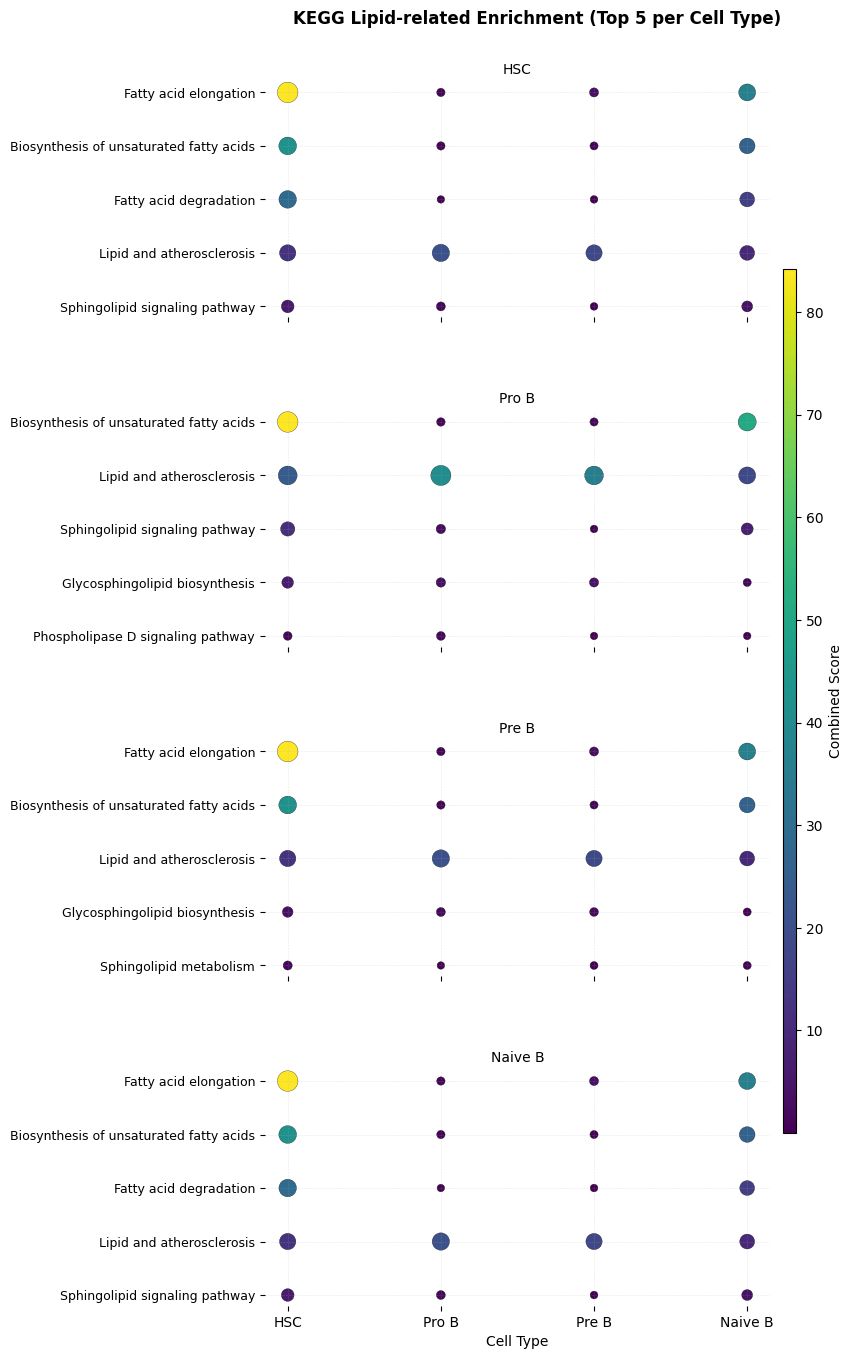

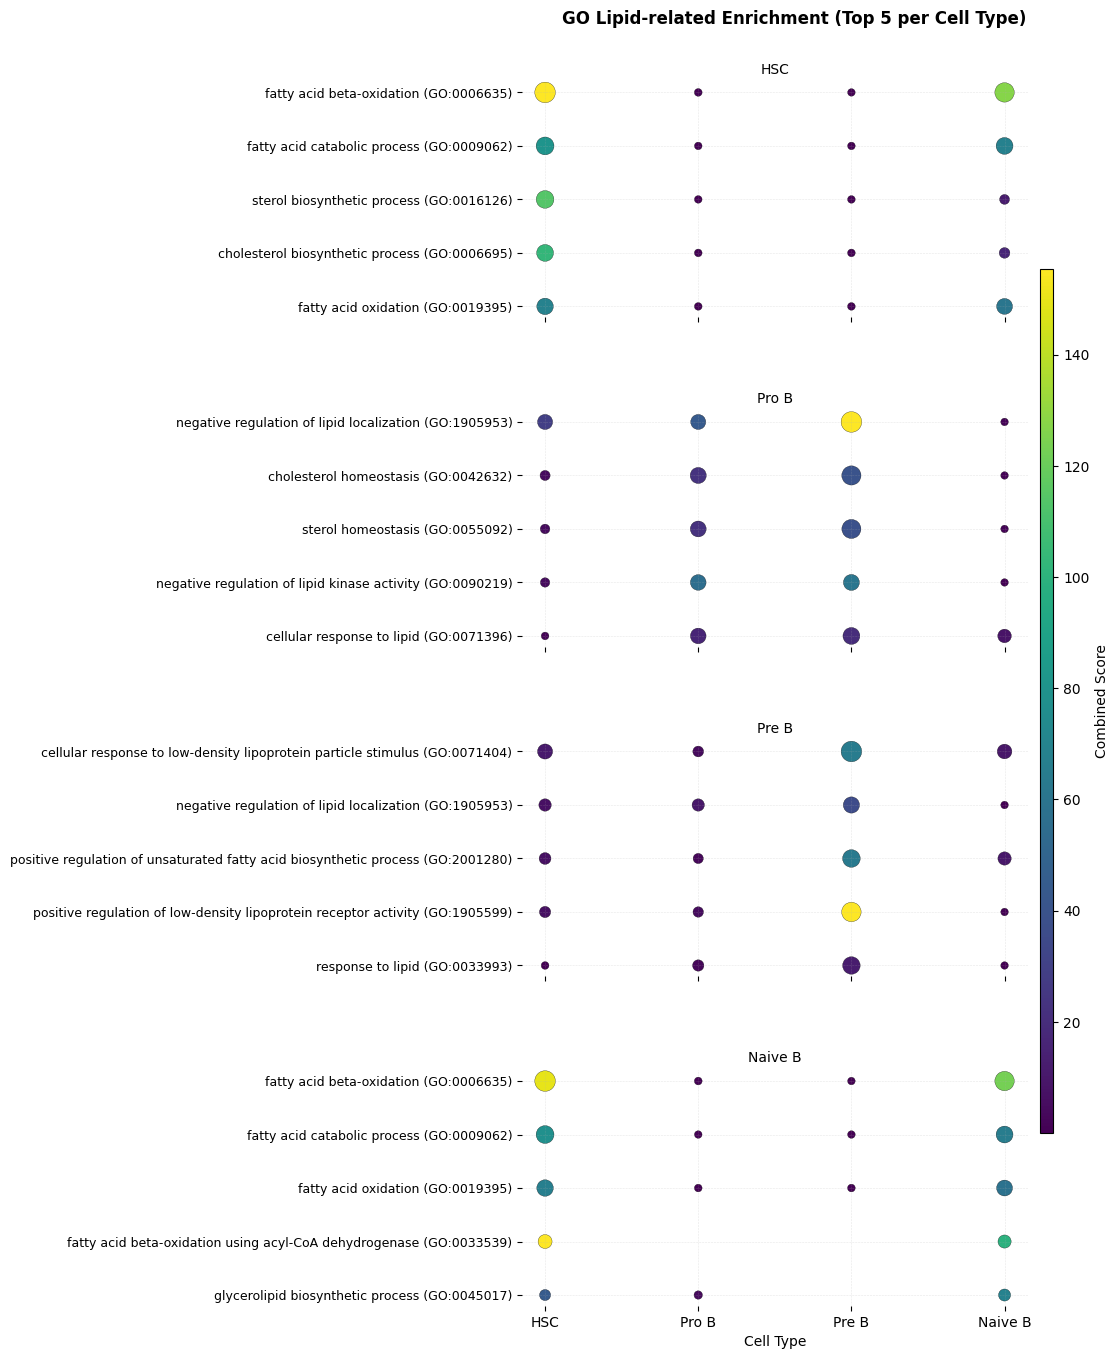

In [79]:
# Lipid-related terms only: top5 per cell type, facet by cell type
lipid_keywords = [
    "lipid", "lipoprotein", "fatty acid", "cholesterol", "sterol", "phospholipid",
    "sphingo", "glycerol", "triglyceride", "lipase"
]

def plot_lipid_facet_by_celltype(df, title, fname):
    if df.empty:
        print(f"No lipid-related enrichment results for {title}")
        return
    df = df.copy()
    df["neg_log10_p"] = -np.log10(df["Adjusted P-value"] + 1e-12)
    cell_order = order if "order" in globals() else sorted(df["cell_type"].unique())
    df["cell_type"] = pd.Categorical(df["cell_type"], categories=cell_order, ordered=True)
    # Build facet data: for each cell type, take its top5 terms, then show those terms across all cell types
    facet_rows = []
    for ct in cell_order:
        top_terms = (
            df[df["cell_type"] == ct]
            .sort_values("Adjusted P-value")
            .head(5)["Term"].tolist()
        )
        if not top_terms:
            continue
        sub = df[df["Term"].isin(top_terms)].copy()
        sub["facet_ct"] = ct
        facet_rows.append(sub)
    if not facet_rows:
        print(f"No terms to plot for {title}")
        return
    plot_df = pd.concat(facet_rows, ignore_index=True)
    # Order terms within each facet by significance in that facet's cell type
    plot_df["Term"] = plot_df.groupby("facet_ct")["Term"].transform(
        lambda s: pd.Categorical(s, categories=list(dict.fromkeys(s.tolist())), ordered=True)
    )
    g = sns.FacetGrid(
        plot_df,
        row="facet_ct",
        row_order=cell_order,
        sharex=True,
        sharey=False,
        height=3.6,
        aspect=1.8,
    )
    g.map_dataframe(
        sns.scatterplot,
        x="cell_type",
        y="Term",
        size="neg_log10_p",
        hue="Combined Score",
        sizes=(30, 220),
        palette="viridis",
        edgecolor="black",
        linewidth=0.2,
        legend=False,
    )
    g.set_titles(row_template="{row_name}")
    g.set_axis_labels("Cell Type", "")
    for ax in g.axes.flatten():
        ax.grid(True, axis="both", linestyle="--", linewidth=0.4, alpha=0.3)
        ax.tick_params(axis="x", labelrotation=0, labelsize=10)
        ax.tick_params(axis="y", labelsize=9)
        for spine in ax.spines.values():
            spine.set_visible(False)
    # Colorbar on the right for Combined Score
    norm = plt.Normalize(plot_df["Combined Score"].min(), plot_df["Combined Score"].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    g.fig.set_constrained_layout(False)
    g.fig.subplots_adjust(left=0.08, right=0.86, top=0.93, bottom=0.08, hspace=0.4)
    cax = g.fig.add_axes([0.88, 0.2, 0.02, 0.6])
    g.fig.colorbar(sm, cax=cax, label="Combined Score")
    g.fig.suptitle(title, fontsize=12, weight="bold")
    for ext in ["svg", "png", "pdf"]:
        g.savefig(out_fig3 / f"{fname}.{ext}", dpi=300, bbox_inches="tight")
    plt.show()

if enrich_df.empty:
    print("No enrichment results to plot")
else:
    pattern = "|".join(lipid_keywords)
    lipid = enrich_df[enrich_df["Term"].str.contains(pattern, case=False, na=False)].copy()
    if lipid.empty:
        print("No lipid-related terms found")
    else:
        # Split by category and plot separately
        for cat, fname in [("KEGG", "lipid_kegg_top5_facet"), ("GO", "lipid_go_top5_facet")]:
            sub = lipid[lipid["category"] == cat].copy()
            if sub.empty:
                print(f"No lipid-related terms found for {cat}")
                continue
            plot_lipid_facet_by_celltype(
                sub,
                f"{cat} Lipid-related Enrichment (Top 5 per Cell Type)",
                fname,
            )
